In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

## Comparison of baselines

In [6]:
def plot_scheduler_radar(data, title="Radar Plot"):
    """
    Generate a radar chart for scheduling algorithms from a complex results dict.
    Includes Carbon Emissions as a factor, and flips 'lower-is-better' metrics so
    that higher is always better (outward = better performance).

    Parameters
    ----------
    data : dict
        Dictionary in the form:
        {
            "Algo Name": {
                "Avg Wait": value,
                "Max Wait": value,
                "Avg Response": value,
                "Avg Slowdown": value,
                "System Utilization": value,
                "Carbon Emissions": value,
                ...
            },
            ...
        }
    title : str
        Title for the radar chart.
    """

    # Metrics to plot
    metrics = ["Avg Wait", "Max Wait", "Avg Response", 
               "Avg Slowdown", "System Utilization", "Carbon Emissions"]
    num_vars = len(metrics)

    # Define which metrics should be inverted (lower is better → higher is better)
    invert_metrics = {"Avg Wait", "Max Wait", "Avg Response", 
                      "Avg Slowdown", "Carbon Emissions"}

    # Collect raw values
    all_values = {m: [float(algo[m]) for algo in data.values()] for m in metrics}
    mins = {m: min(v) for m,v in all_values.items()}
    maxs = {m: max(v) for m,v in all_values.items()}

    # Angles for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    for algo, values in data.items():
        stats = []
        for m in metrics:
            raw_val = float(values[m])

            # normalize to [0,1]
            if maxs[m] > mins[m]:
                norm_val = (raw_val - mins[m]) / (maxs[m] - mins[m])
            else:
                norm_val = 0.5  # if identical across algos

            # invert if lower is better
            if m in invert_metrics:
                norm_val = 1 - norm_val

            stats.append(norm_val)

        stats += stats[:1]  # close loop
        ax.plot(angles, stats, label=algo)
        ax.fill(angles, stats, alpha=0.1)

    # Set axis labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=10)

    plt.title(title, size=14, y=1.1)
    plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.show()


In [9]:
## Global cutoff
batch_baselines = {'FCFS Baseline': {'Avg Wait': np.float64(4552.721755725191),
  'Max Wait': np.float64(4552.721755725191),
  'Avg Response': np.float64(8991.09351145038),
  'Avg Slowdown': np.float64(127.53263829568381),
  'Carbon Emissions': np.float64(9349788.624349324),
  'Weighted Carbon Emissions': np.float64(-9349788.624349324),
  'System Utilization': np.float64(0.45633334506960394),
  'Action Analysis': {'Total Actions': 10603,
   'Schedule Action Percentage': 24.70998773931906,
   'Fixed Delay Percentage': 24.38932377628973,
   'Wait Delay Percentage': 50.90068848439121,
   'Fixed Delays': {'300s': 2586},
   'Wait for Jobs': {'1 jobs': 5397}}},

 '25-percentile Baseline': {'Avg Wait': np.float64(1810750.4419847329),
  'Max Wait': np.float64(1810750.4419847329),
  'Avg Response': np.float64(1815188.813740458),
  'Avg Slowdown': np.float64(77316.16804787882),
  'Carbon Emissions': np.float64(7414982.007835972),
  'Weighted Carbon Emissions': np.float64(-7414982.007835972),
  'System Utilization': np.float64(0.14357239892799886),
  'Action Analysis': {'Total Actions': 35001,
   'Schedule Action Percentage': 7.485500414273878,
   'Fixed Delay Percentage': 85.2689923145053,
   'Wait Delay Percentage': 7.245507271220822,
   'Fixed Delays': {'300s': 29845},
   'Wait for Jobs': {'1 jobs': 2536}}},
 '50-percentile Baseline': {'Avg Wait': np.float64(246734.27366412213),
  'Max Wait': np.float64(246734.27366412213),
  'Avg Response': np.float64(251172.64541984734),
  'Avg Slowdown': np.float64(10490.438944548267),
  'Carbon Emissions': np.float64(9405517.288537573),
  'Weighted Carbon Emissions': np.float64(-9405517.288537573),
  'System Utilization': np.float64(0.44396532014068946),
  'Action Analysis': {'Total Actions': 12895,
   'Schedule Action Percentage': 20.317952694842962,
   'Fixed Delay Percentage': 53.23768902675455,
   'Wait Delay Percentage': 26.44435827840248,
   'Fixed Delays': {'300s': 6865},
   'Wait for Jobs': {'1 jobs': 3410}}},
 'FCFS + EASY Backfilling Baseline': {'Avg Wait': np.float64(21439.271374045802),
  'Max Wait': np.float64(21439.271374045802),
  'Avg Response': np.float64(25877.643129770993),
  'Avg Slowdown': np.float64(43.31848497528734),
  'Carbon Emissions': np.float64(8949341.650160745),
  'Weighted Carbon Emissions': np.float64(-8949341.650160745),
  'System Utilization': np.float64(0.4547249584942782),
  'Action Analysis': {'Total Actions': 9896,
   'Schedule Action Percentage': 26.475343573160874,
   'Fixed Delay Percentage': 18.936944219886822,
   'Wait Delay Percentage': 54.5877122069523,
   'Fixed Delays': {'300s': 1874},
   'Wait for Jobs': {'1 jobs': 5402}}},
   'seed_1_1500000_steps.zip': {'Avg Wait': np.float64(63645.93282442748),
  'Max Wait': np.float64(63645.93282442748),
  'Avg Response': np.float64(68084.30458015268),
  'Avg Slowdown': np.float64(2765.9974486387514),
  'Carbon Emissions': np.float64(9035064.591793105),
  'Weighted Carbon Emissions': np.float64(-9035064.591793105),
  'System Utilization': np.float64(0.44737427430532156),
  'Action Analysis': {'Total Actions': 9789,
   'Schedule Action Percentage': 26.76473592808254,
   'Fixed Delay Percentage': 51.28205128205128,
   'Wait Delay Percentage': 21.953212789866175,
   'Fixed Delays': {'3000s': 83,
    '1800s': 49,
    '3600s': 816,
    '2400s': 90,
    '300s': 2257,
    '600s': 402,
    '1200s': 1323},
   'Wait for Jobs': {'2 jobs': 182, '1 jobs': 1595, '3 jobs': 372}}},
   }
## Global cutoff
interactive_baseline = {'FCFS Baseline': {'Avg Wait': np.float64(227.95801526717557),
  'Max Wait': np.float64(227.95801526717557),
  'Avg Response': np.float64(2452.6431297709923),
  'Avg Slowdown': np.float64(15.81401003654078),
  'Carbon Emissions': np.float64(1839015.1510775986),
  'Weighted Carbon Emissions': np.float64(-1839015.1510775986),
  'System Utilization': np.float64(0.23403978974110695),
  'Action Analysis': {'Total Actions': 9900,
   'Schedule Action Percentage': 26.464646464646464,
   'Fixed Delay Percentage': 22.8989898989899,
   'Wait Delay Percentage': 50.63636363636363,
   'Fixed Delays': {'300s': 2267},
   'Wait for Jobs': {'1 jobs': 5013}}},
 '10-percentile Baseline': {'Avg Wait': np.float64(1638081.5942748091),
  'Max Wait': np.float64(1638081.5942748091),
  'Avg Response': np.float64(1640306.279389313),
  'Avg Slowdown': np.float64(205764.38684356367),
  'Carbon Emissions': np.float64(2496823.188948559),
  'Weighted Carbon Emissions': np.float64(-2496823.188948559),
  'System Utilization': np.float64(0.0737088581383978),
  'Action Analysis': {'Total Actions': 21802,
   'Schedule Action Percentage': 12.01724612420879,
   'Fixed Delay Percentage': 76.59847720392624,
   'Wait Delay Percentage': 11.384276671864967,
   'Fixed Delays': {'300s': 16700},
   'Wait for Jobs': {'1 jobs': 2482}}},
 '25-percentile Baseline': {'Avg Wait': np.float64(1114787.386259542),
  'Max Wait': np.float64(1114787.386259542),
  'Avg Response': np.float64(1117012.071374046),
  'Avg Slowdown': np.float64(140069.23203469565),
  'Carbon Emissions': np.float64(1589614.8086668518),
  'Weighted Carbon Emissions': np.float64(-1589614.8086668518),
  'System Utilization': np.float64(0.15231916301372964),
  'Action Analysis': {'Total Actions': 13796,
   'Schedule Action Percentage': 18.991011887503625,
   'Fixed Delay Percentage': 63.011017686285875,
   'Wait Delay Percentage': 17.997970426210497,
   'Fixed Delays': {'300s': 8693},
   'Wait for Jobs': {'1 jobs': 2483}}},
 '50-percentile Baseline': {'Avg Wait': np.float64(202526.87290076335),
  'Max Wait': np.float64(202526.87290076335),
  'Avg Response': np.float64(204751.5580152672),
  'Avg Slowdown': np.float64(24768.110094578),
  'Carbon Emissions': np.float64(1872448.623187894),
  'Weighted Carbon Emissions': np.float64(-1872448.623187894),
  'System Utilization': np.float64(0.23047905923857034),
  'Action Analysis': {'Total Actions': 11514,
   'Schedule Action Percentage': 22.754907069654333,
   'Fixed Delay Percentage': 54.029876671877716,
   'Wait Delay Percentage': 23.21521625846795,
   'Fixed Delays': {'300s': 6221},
   'Wait for Jobs': {'1 jobs': 2673}}},
 'FCFS + EASY Backfilling Baseline': {'Avg Wait': np.float64(588.856106870229),
  'Max Wait': np.float64(588.856106870229),
  'Avg Response': np.float64(2813.541221374046),
  'Avg Slowdown': np.float64(21.445671130770435),
  'Carbon Emissions': np.float64(1859263.3908662575),
  'Weighted Carbon Emissions': np.float64(-1859263.3908662575),
  'System Utilization': np.float64(0.23403978974110695),
  'Action Analysis': {'Total Actions': 9857,
   'Schedule Action Percentage': 26.580095363700924,
   'Fixed Delay Percentage': 22.542355686314295,
   'Wait Delay Percentage': 50.877548949984785,
   'Fixed Delays': {'300s': 2222},
   'Wait for Jobs': {'1 jobs': 5015}}},
   
   }

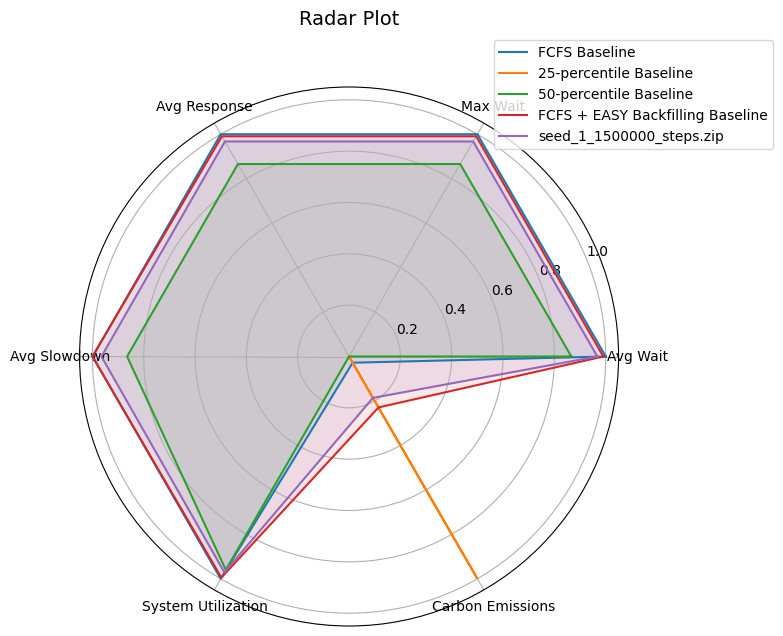

In [10]:
plot_scheduler_radar(batch_baselines)

In [ ]:
'seed_1_1500000_steps.zip': {'Avg Wait': np.float64(63645.93282442748),
  'Max Wait': np.float64(63645.93282442748),
  'Avg Response': np.float64(68084.30458015268),
  'Avg Slowdown': np.float64(2765.9974486387514),
  'Carbon Emissions': np.float64(9035064.591793105),
  'Weighted Carbon Emissions': np.float64(-9035064.591793105),
  'System Utilization': np.float64(0.44737427430532156),
  'Action Analysis': {'Total Actions': 9789,
   'Schedule Action Percentage': 26.76473592808254,
   'Fixed Delay Percentage': 51.28205128205128,
   'Wait Delay Percentage': 21.953212789866175,
   'Fixed Delays': {'3000s': 83,
    '1800s': 49,
    '3600s': 816,
    '2400s': 90,
    '300s': 2257,
    '600s': 402,
    '1200s': 1323},
   'Wait for Jobs': {'2 jobs': 182, '1 jobs': 1595, '3 jobs': 372}}},

## Workload  statistics

In [6]:
def create_job_df(path):
    rows = []
    with open(path) as fp:
        for line in fp:
            if line.startswith(";"):
                continue
            line = line.strip()
            s_array = re.split(r"\s+", line)
            
            # Append to standard Python lists
            submit_time = int(s_array[1])
            req_processors = int(s_array[4])
            req_run_time = int(s_array[3])

            rows.append({"submit_time": submit_time, "requested_processors": req_processors, "requested_runtime": req_run_time})

    return pd.DataFrame(rows);

def plot_workload_patterns(
    df: pd.DataFrame,
    origin="2021-01-01",
    time_unit="s",                 # "s" if submit_time is in seconds; use "ms" if milliseconds, etc.
    runtime_bins_hours=None,       # custom edges in HOURS; leave None to use fine short bins below
    runtime_clip_q=None            # e.g., 0.995 to clip long tail before binning; or None
):
    need = {"submit_time", "requested_runtime", "requested_processors"}
    miss = need - set(df.columns)
    if miss:
        raise ValueError(f"Missing columns: {sorted(miss)}")

    df = df.copy()
    df["submit_time"] = pd.to_numeric(df["submit_time"], errors="coerce")
    df["requested_runtime"] = pd.to_numeric(df["requested_runtime"], errors="coerce")
    df["requested_processors"] = pd.to_numeric(df["requested_processors"], errors="coerce")
    df = df.dropna(subset=["submit_time"])
    df = df[df["submit_time"] >= 0]

    # Build timestamps from submit_time
    t0 = pd.to_datetime(origin)
    df["timestamp"] = t0 + pd.to_timedelta(df["submit_time"], unit=time_unit)
    df["hour"] = df["timestamp"].dt.hour

    # ---------- Weekly job submissions (avg per weekday) ----------
    per_day = df.set_index("timestamp").resample("D").size().rename("count")
    weekly_avg = (
        per_day.groupby(per_day.index.weekday).mean().reindex(range(7), fill_value=0.0)
    )
    plt.figure()
    plt.bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], weekly_avg.values)
    plt.xlabel("Day of week"); plt.ylabel("Average submissions per day")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Monthly job submissions (avg per day, Jan..Dec across all years) ----------
    # Use resampled daily series so months without submissions still contribute 0 days.
    monthly_avg_per_day = (
        per_day.groupby(per_day.index.month)   # 1..12 across all years
        .mean()
        .reindex(range(1,13), fill_value=0.0)
    )
    plt.figure()
    plt.bar(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
            monthly_avg_per_day.values)
    plt.xlabel("Month"); plt.ylabel("Average submissions per day")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Hour-of-day submission pattern (percentage) ----------
    hour_pct = (
        df["hour"].value_counts(normalize=True)
        .reindex(range(24), fill_value=0.0)
        .sort_index() * 100.0
    )
    plt.figure()
    plt.bar(range(24), hour_pct.values)
    plt.xlabel("Hour of day"); plt.ylabel("Percentage of submissions")
    plt.xticks(range(24))
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Job size distribution (processors) ----------
    sizes = df["requested_processors"].dropna()
    sizes = sizes[sizes > 0]
    size_bins = [1, 4, 8, 32, 128, 256, np.inf]
    size_labels = ["1-4", "4-8", "8-32", "32-128", "128-256", "256"]
    cat = pd.cut(sizes, size_bins, right=False, include_lowest=True, labels=size_labels)
    dist_pct = (cat.value_counts().sort_index() / len(sizes)) * 100.0
    plt.figure()
    plt.bar(dist_pct.index.astype(str), dist_pct.values)
    plt.xlabel("Job size bins"); plt.ylabel("Percentage")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Distribution of requested runtimes (hours) — fine short bins ----------
    rt_h = (df["requested_runtime"].dropna() / 3600.0)
    rt_h = rt_h[rt_h > 0]
    if len(rt_h) == 0:
        plt.figure(); plt.title("Distribution of requested runtimes (hours)")
        plt.text(0.5, 0.5, "No positive runtimes", ha="center"); plt.axis("off"); plt.show()
        return

    if runtime_clip_q:
        rt_h = rt_h.clip(upper=float(rt_h.quantile(runtime_clip_q)))

    # Default: extra-fine bins at short end (minutes), then hour bins
    if runtime_bins_hours is None:
        mins = np.array([0,1, 2, 5, 10, 15, 20, 30, 45, 60]) / 60.0
        hrs  = np.array([2, 4, 8, 12, 24, 48, np.inf], dtype=float)
        runtime_bins_hours = np.concatenate([mins, hrs])

    counts, edges = np.histogram(rt_h.values, bins=runtime_bins_hours)
    pct = counts / counts.sum() * 100.0

    def fmt_h(x):
        return f"{x:.0f}h" if x >= 1 else f"{int(round(x*60))}m"

    labels = []
    for i in range(len(edges)-1):
        lo, hi = edges[i], edges[i+1]
        if np.isinf(hi):
            labels.append(f"{fmt_h(lo)}+")
        else:
            labels.append(f"{fmt_h(lo)}–{fmt_h(hi)}")

    plt.figure()
    plt.bar(labels, pct)
    plt.xlabel("Requested runtime bins"); plt.ylabel("Percentage of jobs")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

#### COmparison of different traces

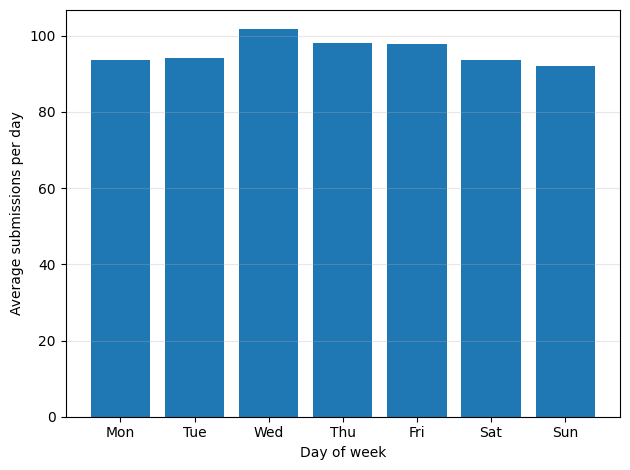

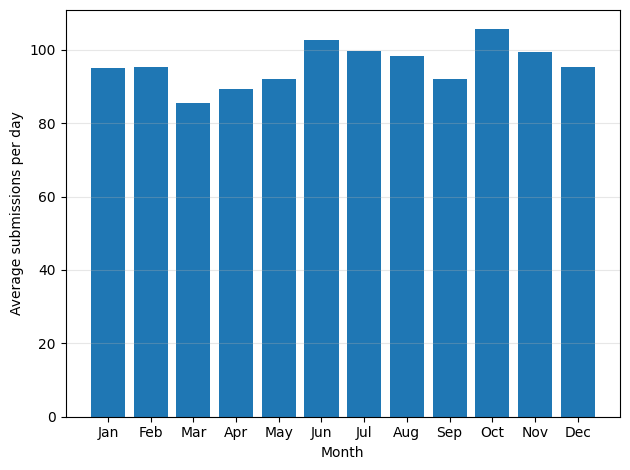

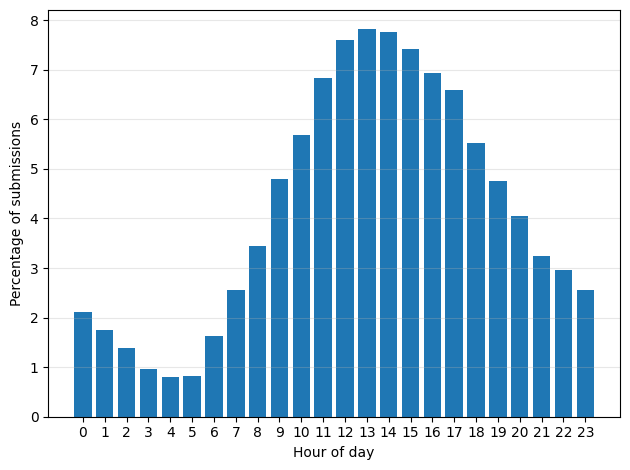

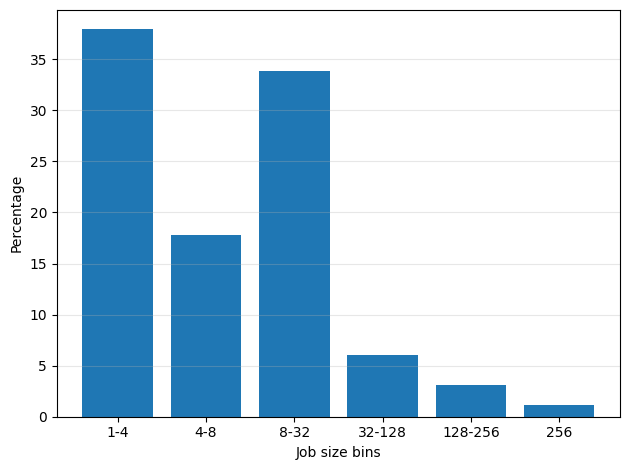

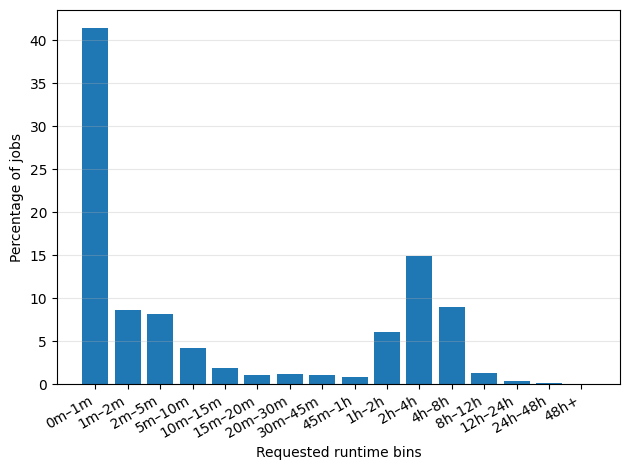

In [14]:
# Non convergent dataset:
WORKLOAD_PATH_BAD = "data/workloads/training_workload_batch.swf"
df_bad = create_job_df(path=WORKLOAD_PATH_BAD)

plot_workload_patterns(df_bad)


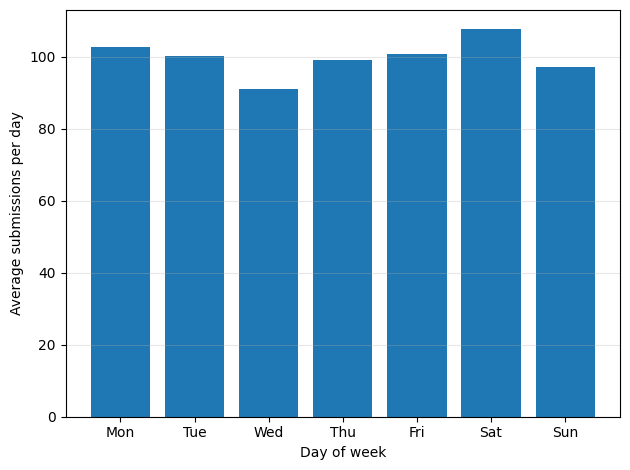

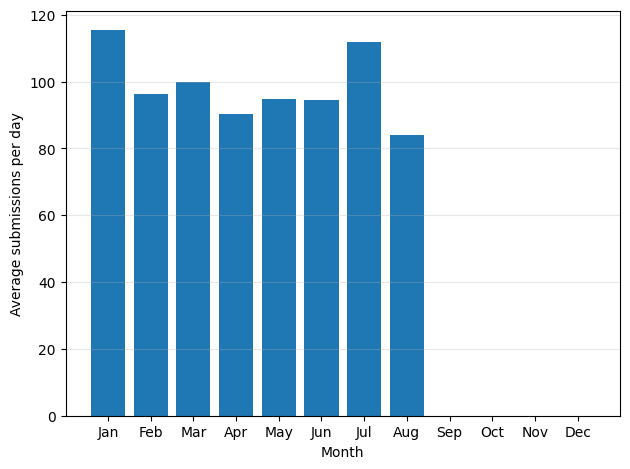

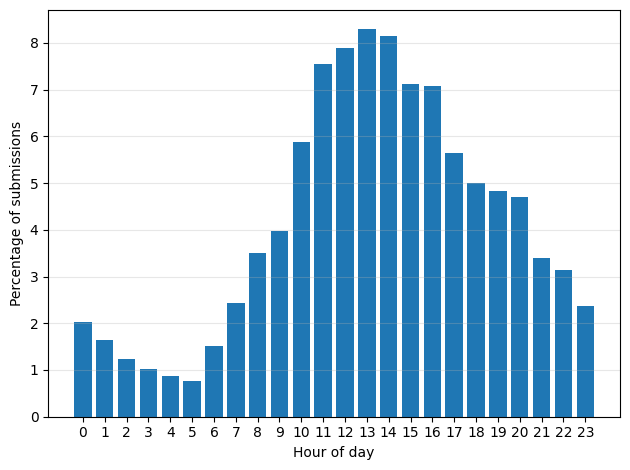

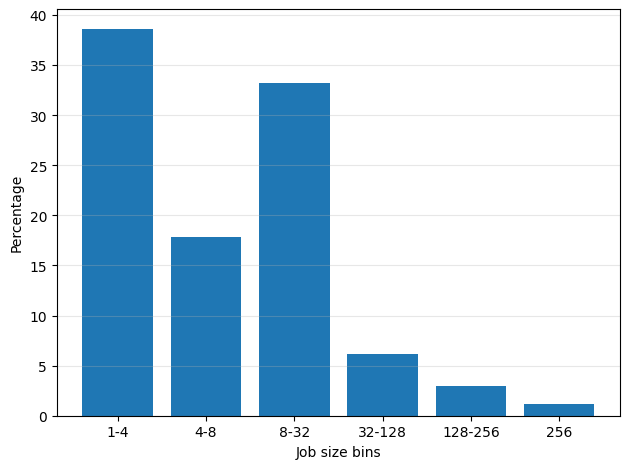

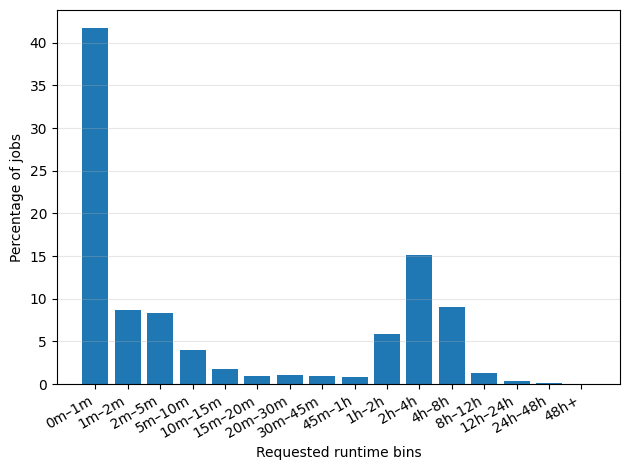

In [9]:
## Non convergent dataset:
WORKLOAD_PATH_BAD = "data/workloads/test_workload_batch.swf" 
df_bad = create_job_df(path=WORKLOAD_PATH_BAD)

plot_workload_patterns(df_bad)

## Interactive workload

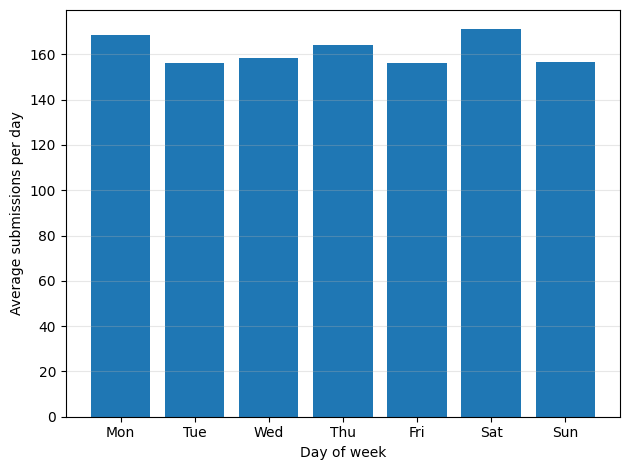

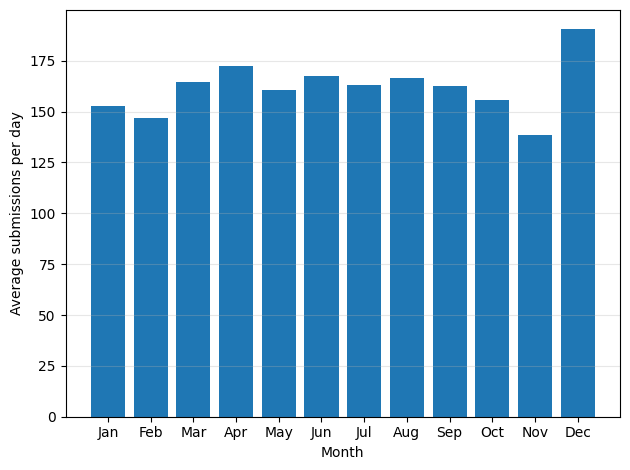

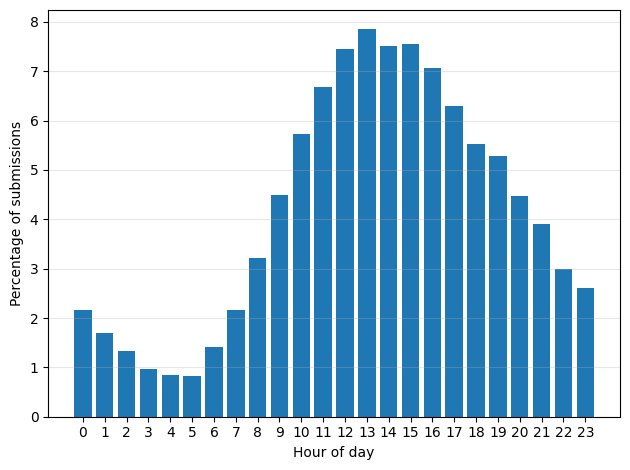

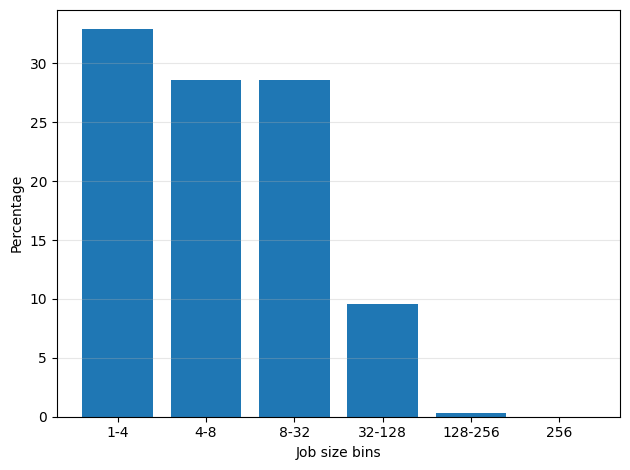

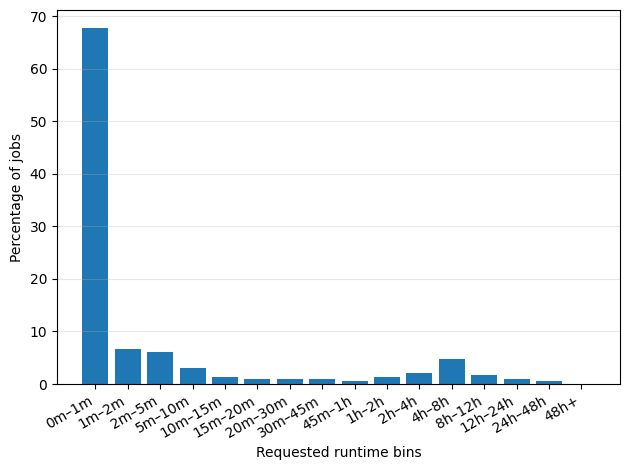

In [20]:
# Non convergent dataset:
WORKLOAD_PATH_BAD = "scripts/workload.swf"
df_bad = create_job_df(path=WORKLOAD_PATH_BAD)

plot_workload_patterns(df_bad)


## Actual workload trace EXA

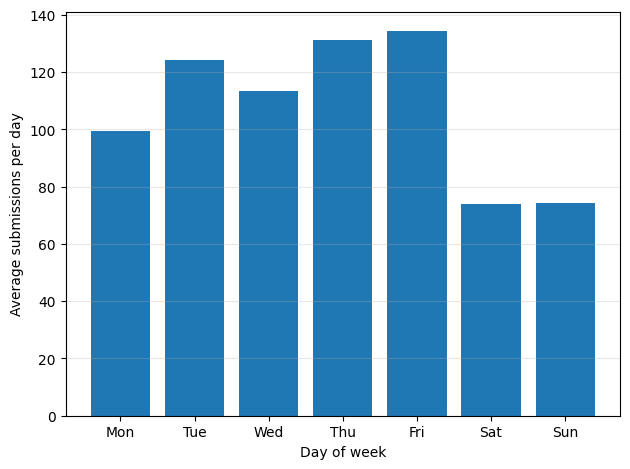

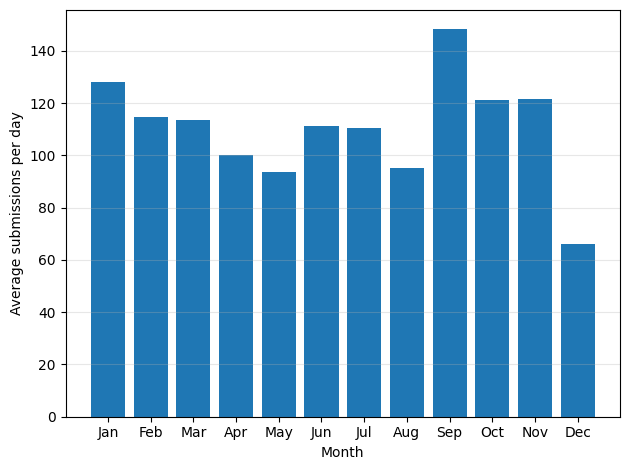

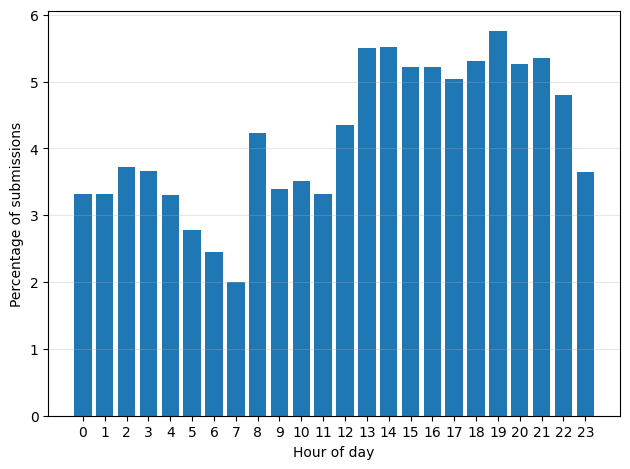

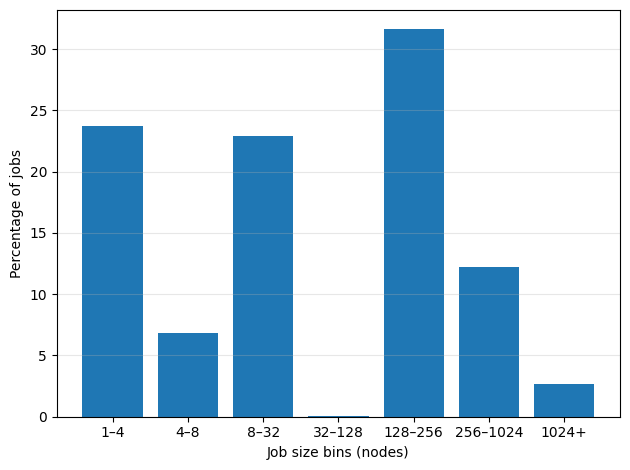

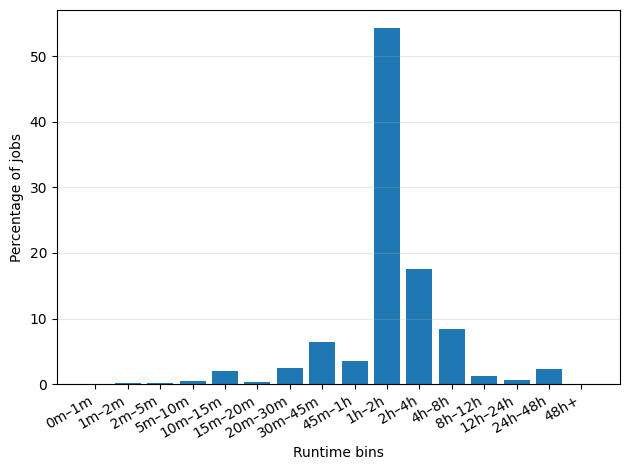

In [18]:

# Path to your CSV file
csv_path = "data/ANL-ALCF-DJC-THETA_20230101_20231231.csv"

# Read the CSV
df_raw = pd.read_csv(csv_path)

# Select only the relevant columns and rename them
df = df_raw[["QUEUED_TIMESTAMP", "NODES_REQUESTED", "WALLTIME_SECONDS"]].rename(
    columns={
        "QUEUED_TIMESTAMP": "submit_time",
        "NODES_REQUESTED": "requested_nodes",
        "WALLTIME_SECONDS": "runtime"
    }
)


def plot_csv_job_patterns(
    df: pd.DataFrame,
    runtime_bins_hours=None,
    runtime_clip_q=None
):
    """
    Create workload-like plots from CSV job data with columns:
      submit_time (datetime64), requested_nodes (int), runtime (seconds)
    """

    need = {"submit_time", "requested_nodes", "runtime"}
    miss = need - set(df.columns)
    if miss:
        raise ValueError(f"Missing columns: {sorted(miss)}")

    # Ensure correct types
    df = df.copy()
    df["submit_time"] = pd.to_datetime(df["submit_time"], errors="coerce")
    df["requested_nodes"] = pd.to_numeric(df["requested_nodes"], errors="coerce")
    df["runtime"] = pd.to_numeric(df["runtime"], errors="coerce")

    df = df.dropna(subset=["submit_time"])
    df = df[df["submit_time"] >= pd.Timestamp("1970-01-01")]

    # Extract hour-of-day
    df["hour"] = df["submit_time"].dt.hour

    # ---------- Weekly job submissions (avg per weekday) ----------
    per_day = df.set_index("submit_time").resample("D").size().rename("count")
    weekly_avg = (
        per_day.groupby(per_day.index.weekday).mean().reindex(range(7), fill_value=0.0)
    )
    plt.figure()
    plt.bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], weekly_avg.values)
    plt.xlabel("Day of week"); plt.ylabel("Average submissions per day")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Monthly job submissions (avg per day) ----------
    monthly_avg_per_day = (
        per_day.groupby(per_day.index.month)
        .mean()
        .reindex(range(1,13), fill_value=0.0)
    )
    plt.figure()
    plt.bar(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
            monthly_avg_per_day.values)
    plt.xlabel("Month"); plt.ylabel("Average submissions per day")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Hour-of-day submission pattern ----------
    hour_pct = (
        df["hour"].value_counts(normalize=True)
        .reindex(range(24), fill_value=0.0)
        .sort_index() * 100.0
    )
    plt.figure()
    plt.bar(range(24), hour_pct.values)
    plt.xlabel("Hour of day"); plt.ylabel("Percentage of submissions")
    plt.xticks(range(24))
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Job size distribution (requested_nodes) ----------
    sizes = df["requested_nodes"].dropna()
    sizes = sizes[sizes > 0]
    size_bins = [1, 4, 8, 32, 128, 256, 1024, np.inf]
    size_labels = ["1–4", "4–8", "8–32", "32–128", "128–256", "256–1024", "1024+"]
    cat = pd.cut(sizes, size_bins, right=False, include_lowest=True, labels=size_labels)
    dist_pct = (cat.value_counts().sort_index() / len(sizes)) * 100.0
    plt.figure()
    plt.bar(dist_pct.index.astype(str), dist_pct.values)
    plt.xlabel("Job size bins (nodes)"); plt.ylabel("Percentage of jobs")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Distribution of runtimes (hours) ----------
    rt_h = df["runtime"].dropna() / 3600.0
    rt_h = rt_h[rt_h > 0]
    if len(rt_h) == 0:
        plt.figure(); plt.title("Distribution of runtimes (hours)")
        plt.text(0.5, 0.5, "No positive runtimes", ha="center"); plt.axis("off"); plt.show()
        return

    if runtime_clip_q:
        rt_h = rt_h.clip(upper=float(rt_h.quantile(runtime_clip_q)))

    if runtime_bins_hours is None:
        mins = np.array([0,1,2,5,10,15,20,30,45,60]) / 60.0
        hrs  = np.array([2,4,8,12,24,48,np.inf], dtype=float)
        runtime_bins_hours = np.concatenate([mins, hrs])

    counts, edges = np.histogram(rt_h.values, bins=runtime_bins_hours)
    pct = counts / counts.sum() * 100.0

    def fmt_h(x):
        return f"{x:.0f}h" if x >= 1 else f"{int(round(x*60))}m"

    labels = []
    for i in range(len(edges)-1):
        lo, hi = edges[i], edges[i+1]
        if np.isinf(hi):
            labels.append(f"{fmt_h(lo)}+")
        else:
            labels.append(f"{fmt_h(lo)}–{fmt_h(hi)}")

    plt.figure()
    plt.bar(labels, pct)
    plt.xlabel("Runtime bins"); plt.ylabel("Percentage of jobs")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

plot_csv_job_patterns(df)

## Carbon intensity statistics

In [ ]:

def read_carbon_csv(path: str) -> pd.DataFrame:
    """
    Reads the CSV and returns a dataframe with columns:
    - timestamp (UTC-aware pandas datetime)
    - value (float)
    """
    # Read first, letting pandas infer headers
    df = pd.read_csv(path, parse_dates=[0])
    # Strip any funny whitespace in headers
    df.columns = [c.strip() for c in df.columns]

    # Robust renaming to standard names
    ts_col = df.columns[0]
    # Try to find the value column by common names
    candidate_value_cols = [c for c in df.columns[1:] if c.strip().lower() in ("value", "carbon intensity", "carbon_intensity", "intensity")]
    value_col = candidate_value_cols[0] if candidate_value_cols else df.columns[1]

    df = df.rename(columns={ts_col: "timestamp", value_col: "value"})

    # Ensure datetime is timezone-aware UTC (source column is UTC)
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    # Drop bad rows
    df = df.dropna(subset=["timestamp", "value"]).sort_values("timestamp").reset_index(drop=True)
    return df


def plot_profile_with_std(x, mean_series, std_series, x_tick_labels, x_label, y_label, outfile):
    """
    Plots mean line with a grey ±1 std band. No title.
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    mean_vals = np.asarray(mean_series.values, dtype=float)
    std_vals = np.asarray(std_series.fillna(0).values, dtype=float)
    lower = mean_vals - std_vals
    upper = mean_vals + std_vals

    # Mask NaNs so plotting works even if some bins have no data
    x = np.asarray(x)
    valid = ~np.isnan(mean_vals)

    ax.plot(x[valid], mean_vals[valid], linewidth=2, label="Mean", color="black")
    ax.fill_between(x[valid], lower[valid], upper[valid], alpha=0.25, label="±1 SD", color="gray")

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(True, linestyle="--", alpha=0.4)

    ax.set_xticks(x)
    ax.set_xticklabels(x_tick_labels, rotation=0)
    ax.legend(loc="best")

    fig.tight_layout()
    fig.savefig(outfile, dpi=150)
    plt.close(fig)

path = "data/DK-DK2_minutely_carbon_intensity_improved.csv"
df = read_carbon_csv(path)

# DAILY PROFILE (by hour 0..23)
by_hour = (
    df.groupby(df["timestamp"].dt.hour)["value"]
    .agg(mean="mean", std="std")
    .reindex(range(24))
)
hours = np.arange(24)
hour_labels = [f"{h:02d}" for h in hours]
plot_profile_with_std(
    x=hours,
    mean_series=by_hour["mean"],
    std_series=by_hour["std"],
    x_tick_labels=hour_labels,
    x_label="Hour of Day (00–23, UTC)",
    y_label="Carbon Intensity",
    outfile="daily_profile.png",
)

# WEEKLY PROFILE (by weekday Mon..Sun)
# Pandas: Monday=0 ... Sunday=6
weekday_order = list(range(7))
weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_weekday = (
    df.groupby(df["timestamp"].dt.dayofweek)["value"]
    .agg(mean="mean", std="std")
    .reindex(weekday_order)
)
plot_profile_with_std(
    x=weekday_order,
    mean_series=by_weekday["mean"],
    std_series=by_weekday["std"],
    x_tick_labels=weekday_names,
    x_label="Weekday",
    y_label="Carbon Intensity",
    outfile="weekly_profile.png",
)

# MONTHLY PROFILE (by month Jan..Dec; month-of-year across all years)
month_order = list(range(1, 13))
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
by_month = (
    df.groupby(df["timestamp"].dt.month)["value"]
        .agg(mean="mean", std="std")
        .reindex(month_order)
)
plot_profile_with_std(
    x=month_order,
    mean_series=by_month["mean"],
    std_series=by_month["std"],
    x_tick_labels=month_names,
    x_label="Month",
    y_label="Carbon intensity",
    outfile="monthly_profile.png",
)

# YEARLY PROFILE (by calendar year)
by_year = df.groupby(df["timestamp"].dt.year)["value"].agg(mean="mean", std="std").sort_index()
years = by_year.index.to_numpy()
year_labels = [str(y) for y in years]
plot_profile_with_std(
    x=years,
    mean_series=by_year["mean"],
    std_series=by_year["std"],
    x_tick_labels=year_labels,
    x_label="Year",
    y_label="Carbon Intensity",
    outfile="yearly_profile.png",
)

print("Saved: daily_profile.png, weekly_profile.png, yearly_profile.png")

Saved: daily_profile.png, weekly_profile.png, yearly_profile.png


In [4]:
import sys
import pandas as pd

def compute_percentiles(csv_path):
    # Load CSV
    df = pd.read_csv(csv_path)
    
    # Make sure Value column exists
    if "Value" not in df.columns:
        raise ValueError("CSV must contain a 'Value' column")
    
    # Convert Value column to numeric (force errors to NaN and drop them)
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    df = df.dropna(subset=["Value"])
    
    # Compute percentiles
    percentiles = df["Value"].quantile([0.10, 0.25, 0.50])
    
    print("Percentiles for 'Value':")
    for p, val in percentiles.items():
        print(f"{int(p*100)}th percentile: {val:.4f}")

compute_percentiles("data/DK-DK2_minutely_carbon_intensity_improved.csv")

/var/folders/9h/bnhs_81n0933zyrnm6nwdg8w0000gn/T/ipykernel_49488/158549358.py:6: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Percentiles for 'Value':
10th percentile: 31.9240
25th percentile: 47.3247
50th percentile: 78.4003
